# Direct Linear-Directional Dependence

Question: at each fixed component count `K`, does a full cylindrical mixture improve temporally held-out prediction over an independent cylindrical mixture with the same `K`?

Primary readout: `delta_hll = HLL_cyl - HLL_ind` on the temporal holdout. Positive values favor direct within-component dependence between transformed sea-state variables and wave direction. For `delta_bic` and `delta_aic`, negative values favor the full cylindrical model because lower BIC/AIC is better.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import experiment.ocean.helpers as mod

NOTEBOOK_DIR = PROJECT_ROOT / "experiment" / "ocean"


## Configuration

The defaults below run the full fixed-`K` comparison: 5 component counts times 30 paired restarts. For a smoke run, set `K_GRID = (1, 2)` and `N_RESTARTS = 1`.


In [2]:
CSV_PATH = mod.DEFAULT_CSV_PATH
FIGURE_PATH = NOTEBOOK_DIR / "cylindrical_dependence_by_k.pdf"

LINEAR_FEATURES = mod.DEFAULT_LINEAR_FEATURES
DIRECTION_FEATURE = mod.DEFAULT_DIRECTION_FEATURE
TRAIN_FRACTION = 0.80

K_GRID = (1, 2, 3, 4, 5, 6)
N_RESTARTS = 5
MAX_ITER = 500
TOL = 1e-4
RANDOM_STATE = 57

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing {CSV_PATH}. Run experiment/ocean/download.ipynb first.")


## Preprocess

This wraps the CSV read, irregular-minute cleanup, temporal split, power transform for the linear variables, and direction conversion to `(cos(mwd), sin(mwd))`.


In [3]:
prepared = mod.prepare_data(
    csv_path=CSV_PATH,
    shuffle=True,
    random_state=157
)

x_train = prepared["x_train"]
x_test = prepared["x_test"]

split_summary = pd.DataFrame.from_records([
    {
        "split": "train",
        "n": len(prepared["train_frame"]),
        "start": prepared["train_time_range"][0],
        "end": prepared["train_time_range"][1],
    },
    {
        "split": "test",
        "n": len(prepared["test_frame"]),
        "start": prepared["test_time_range"][0],
        "end": prepared["test_time_range"][1],
    },
])

split_summary


,split,n,start,end
0,train,149792,2000-01-01 00:00:00+00:00,2022-12-31 23:40:00+00:00
1,test,37449,2000-01-01 02:00:00+00:00,2022-12-31 19:40:00+00:00


In [4]:
feature_summary = pd.DataFrame(x_train, columns=prepared["feature_names"]).describe().T
feature_summary


,count,mean,std,min,25%,50%,75%,max
wvht,149792.0,-4.087499e-16,1.000003,-5.861130,-0.713748,-0.004547,0.716583,3.549409
apd,149792.0,1.681439e-15,1.000003,-16.913220,-0.676694,-0.005939,0.651832,4.109531
wspd,149792.0,-2.923674e-16,1.000003,-2.415206,-0.776605,0.046754,0.772630,3.716265
cos(mwd),149792.0,3.202735e-01,0.515432,-1.000000,0.224951,0.500000,0.656059,1.000000
sin(mwd),149792.0,-7.548297e-01,0.248976,-1.000000,-0.920505,-0.809017,-0.694658,0.999391


## Paired Fixed-K Comparison

Each paired run fits one full cylindrical mixture and one independent cylindrical mixture with the same `K`, train/test split, restart index, and seed. Progress is printed after each pair.


In [5]:
comparison = mod.compare_cylindrical_dependence_by_k(
    x_train,
    x_test,
    d_gauss=prepared["d_gauss"],
    d_vmf=prepared["d_vmf"],
    k_grid=K_GRID,
    n_restarts=5,
    random_state=57,
    show_progress=True,
)

results_df = pd.DataFrame(comparison["results"])
summary_df = pd.DataFrame(comparison["summary"])

summary_df


Finished paired run 1/30 (3.3%) | k=1 | restart=0 | delta_hll=4879.43 | delta_bic=-39141.4 | success
Finished paired run 2/30 (6.7%) | k=1 | restart=1 | delta_hll=4879.43 | delta_bic=-39141.4 | success
Finished paired run 3/30 (10.0%) | k=1 | restart=2 | delta_hll=4879.43 | delta_bic=-39141.4 | success
Finished paired run 4/30 (13.3%) | k=1 | restart=3 | delta_hll=4879.43 | delta_bic=-39141.4 | success
Finished paired run 5/30 (16.7%) | k=1 | restart=4 | delta_hll=4879.43 | delta_bic=-39141.4 | success
Finished paired run 6/30 (20.0%) | k=2 | restart=0 | delta_hll=3245.43 | delta_bic=-26704.9 | success
Finished paired run 7/30 (23.3%) | k=2 | restart=1 | delta_hll=3245.43 | delta_bic=-26704.9 | success
Finished paired run 8/30 (26.7%) | k=2 | restart=2 | delta_hll=3245.43 | delta_bic=-26704.9 | success
Finished paired run 9/30 (30.0%) | k=2 | restart=3 | delta_hll=3245.43 | delta_bic=-26704.9 | success
Finished paired run 10/30 (33.3%) | k=2 | restart=4 | delta_hll=3245.43 | delta_bic=

,k,success,successful_restarts,failed_restarts,delta_hll_mean,delta_hll_median,delta_hll_std,delta_hll_min,delta_hll_max,delta_avg_hll_mean,...,delta_heldout_aic_mean,cross_cov_norm_weighted_mean,cross_cov_norm_weighted_median,cross_cov_norm_max_mean,best_restart_by_cyl_bic,best_seed_by_cyl_bic,best_delta_hll,best_delta_bic,best_delta_aic,best_cross_cov_norm_weighted
0,1,True,5,0,4879.434840,4879.434840,0.000000,4879.434840,4879.434840,0.130295,...,-9746.869681,0.593722,0.593722,0.593722,0,375163855,4879.434840,-39141.353622,-39200.855640,0.593722
1,2,True,5,0,3245.426365,3245.426365,0.000000,3245.426365,3245.426365,0.086663,...,-6466.852729,0.310500,0.310500,0.344227,0,2020362872,3245.426365,-26704.893170,-26823.897205,0.310500
2,3,True,5,0,2088.360022,2088.208883,0.953835,2087.503596,2089.972026,0.055765,...,-4140.720043,0.325114,0.325030,0.381318,0,193547127,2088.283265,-17344.986002,-17523.492055,0.325025
3,4,True,5,0,1231.903255,1231.753809,1.346907,1230.453229,1233.996066,0.032895,...,-2415.806511,0.222912,0.222731,0.337198,1,94879057,1233.996066,-10058.529835,-10296.537906,0.222461
4,5,True,5,0,734.888267,579.776134,352.056959,571.760584,1364.629903,0.019624,...,-1409.776534,0.224828,0.224417,0.339615,3,1346502342,1364.629903,-11762.519184,-12060.029272,0.227865
5,6,True,5,0,500.707725,608.787384,253.756441,48.246337,646.563224,0.013370,...,-929.415450,0.216417,0.211258,0.364965,1,352916569,646.563224,-5643.003286,-6000.015392,0.183204


## Tables

Use the summary table for the report-level readout, then check failed runs before interpreting restart averages.


In [6]:
summary_columns = [
    "k",
    "successful_restarts",
    "failed_restarts",
    "delta_hll_mean",
    "delta_hll_std",
    "best_delta_hll",
    "delta_avg_hll_mean",
    "delta_avg_hll_std",
    "delta_bic_mean",
    "delta_aic_mean",
    "cross_cov_norm_weighted_mean",
]

summary_view = summary_df.loc[:, [column for column in summary_columns if column in summary_df.columns]]
summary_view


,k,successful_restarts,failed_restarts,delta_hll_mean,delta_hll_std,best_delta_hll,delta_avg_hll_mean,delta_avg_hll_std,delta_bic_mean,delta_aic_mean,cross_cov_norm_weighted_mean
0,1,5,0,4879.434840,0.000000,4879.434840,0.130295,0.000000,-39141.353622,-39200.855640,0.593722
1,2,5,0,3245.426365,0.000000,3245.426365,0.086663,0.000000,-26704.893170,-26823.897205,0.310500
2,3,5,0,2088.360022,0.953835,2088.283265,0.055765,0.000025,-17345.712290,-17524.218343,0.325114
3,4,5,0,1231.903255,1.346907,1233.996066,0.032895,0.000036,-10042.558983,-10280.567054,0.222912
4,5,5,0,734.888267,352.056959,1364.629903,0.019624,0.009401,-6618.192283,-6915.702371,0.224828
5,6,5,0,500.707725,253.756441,646.563224,0.013370,0.006776,-4573.111257,-4930.123363,0.216417


In [7]:
failure_columns = [column for column in ("k", "restart", "seed", "error") if column in results_df.columns]
failed_runs = results_df.loc[~results_df["success"], failure_columns]
failed_runs


,k,restart,seed


## Visual Checks

Top panel: held-out evidence for direct dependence. Middle panel: BIC/AIC differences. Bottom panel: fitted cross-dependence strength. Positive `delta_hll` favors the full model; negative `delta_bic` and `delta_aic` favor the full model.


PosixPath('/Users/jgv/PycharmProjects/cylindrical-data-lvm/experiment/ocean/cylindrical_dependence_by_k.pdf')

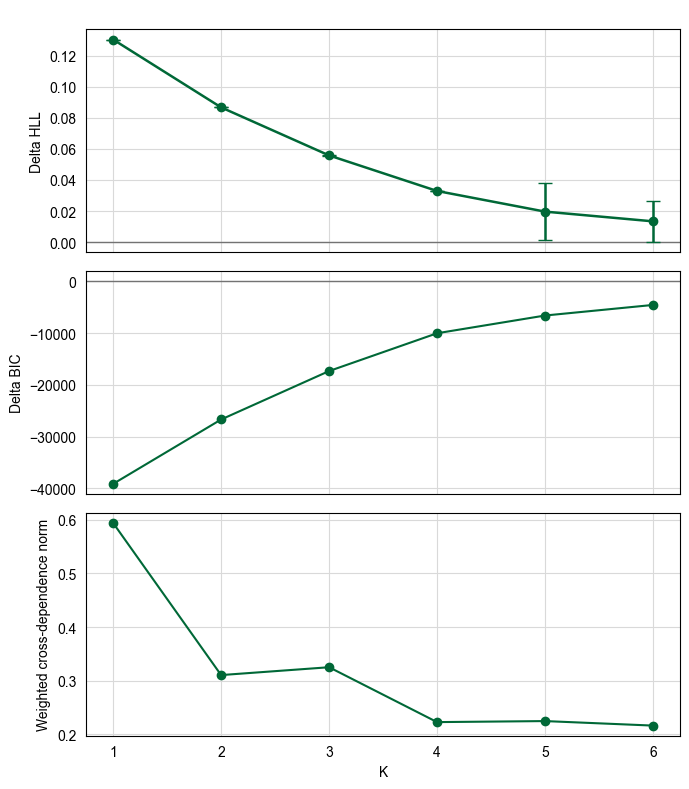

In [9]:
k_values = summary_df["k"].astype(int)
hll_yerr = summary_df["delta_avg_hll_std"].fillna(0.0).mul(1.96)
color="#006837"

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

axes[0].axhline(0, color="0.45", linewidth=1)
axes[0].errorbar(
    k_values,
    summary_df["delta_avg_hll_mean"],
    yerr=hll_yerr,
    marker="o",
    capsize=5,
    linewidth=1.8,
    color=color
)
axes[0].set_ylabel("Delta HLL")
axes[0].set_title("Held-out evidence for dependence")

axes[1].axhline(0, color="0.45", linewidth=1)
axes[1].plot(k_values, summary_df["delta_bic_mean"], marker="o", label="BIC",color=color)
axes[1].set_ylabel("Delta BIC")
#axes[1].legend(frameon=False)

axes[2].plot(
    k_values,
    summary_df["cross_cov_norm_weighted_mean"],
    color=color,
    marker="o",
)
axes[2].set_xlabel("K")
axes[2].set_ylabel("Weighted cross-dependence norm")
axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[2].set_xticks(k_values)

fig.patch.set_facecolor("white")
fig.patch.set_alpha(1)

for ax in axes:
    ax.set_facecolor("white")
    ax.patch.set_alpha(1)
    ax.grid(True, axis="both", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("black")

fig.tight_layout()
fig.savefig(
    FIGURE_PATH,
    format="pdf",
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white",
    transparent=False,
)

FIGURE_PATH
